Objective : The objective of this assignment is to evaluate different regression algorithms using the California Housing Dataset.

1. Loading and Preprocessing

In [1]:

import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

2. Load Dataset
Load California Housing Dataset

In [3]:
housing = fetch_california_housing()
# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
# Add target variable
df['MedbangloreHouseVal'] = housing.target
# Display first few rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
The California Housing dataset was loaded using fetch_california_housing() and converted into a pandas DataFrame for easier analysis

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.isnull().sum()


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Observation : No missing values were found in the dataset. So, no missing value treatment was required.

3: Feature Selection

In [9]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

4 :Train-Test Split -  The dataset will be divided into 80% training data and 20% testing data.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

5:Standardization - Feature scaling was performed using StandardScaler. Scaling ensures that all features have similar magnitudes and improves the performance of algorithms such as Linear Regression and Support Vector Regression.

In [23]:


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



6: Create Evaluation Function - 

In [21]:

def evaluate_model(model,
                   X_train,
                   X_test,
                   y_train,
                   y_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)

    mae = mean_absolute_error(y_test, predictions)

    r2 = r2_score(y_test, predictions)

    return mse, mae, r2


7: Linear Regression
Linear Regression models a linear relationship between input variables and the target variable.

In [13]:

lr = LinearRegression()

lr_results = evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

lr_results

(0.5558915986952444, 0.5332001304956565, 0.5757877060324508)

8: Decision Tree Regressor : Decision Trees split the dataset into smaller regions and predict values using the average target value in each region.

In [14]:

dt = DecisionTreeRegressor(
    random_state=42
)

dt_results = evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

dt_results

(0.494255717630063, 0.4541711942829458, 0.622823312540521)

9: Random Forest Regressor : Random Forest combines multiple decision trees and averages their predictions to improve accuracy.

In [24]:

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_results

(0.25602182673365537, 0.32773108008720936, 0.8046244867176197)

10: Gradient Boosting Regressor : 
Gradient Boosting builds trees sequentially and each tree attempts to correct errors from previous trees


In [25]:

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr_results = evaluate_model(
    gbr,
    X_train,
    X_test,
    y_train,
    y_test
)

gbr_results

(0.2939973248643864, 0.37164256904255966, 0.7756446042829697)

11: Support Vector Regressor : SVR attempts to find a regression line within a margin of tolerance while maximizing generalization.

In [26]:
svr = SVR()

svr_results = evaluate_model(
    svr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

svr_results

(0.3570040319338646, 0.39859907695205243, 0.7275628923016776)

12: Final Comparison Output : 

In [27]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],

    "MSE": [
        lr_results[0],
        dt_results[0],
        rf_results[0],
        gbr_results[0],
        svr_results[0]
    ],

    "MAE": [
        lr_results[1],
        dt_results[1],
        rf_results[1],
        gbr_results[1],
        svr_results[1]
    ],

    "R2": [
        lr_results[2],
        dt_results[2],
        rf_results[2],
        gbr_results[2],
        svr_results[2]
    ]
})

results.sort_values(
    by="R2",
    ascending=False
)

,Model,MSE,MAE,R2
2,Random Forest,0.256022,0.327731,0.804624
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563
1,Decision Tree,0.494256,0.454171,0.622823
0,Linear Regression,0.555892,0.533200,0.575788


13: Visual Representation

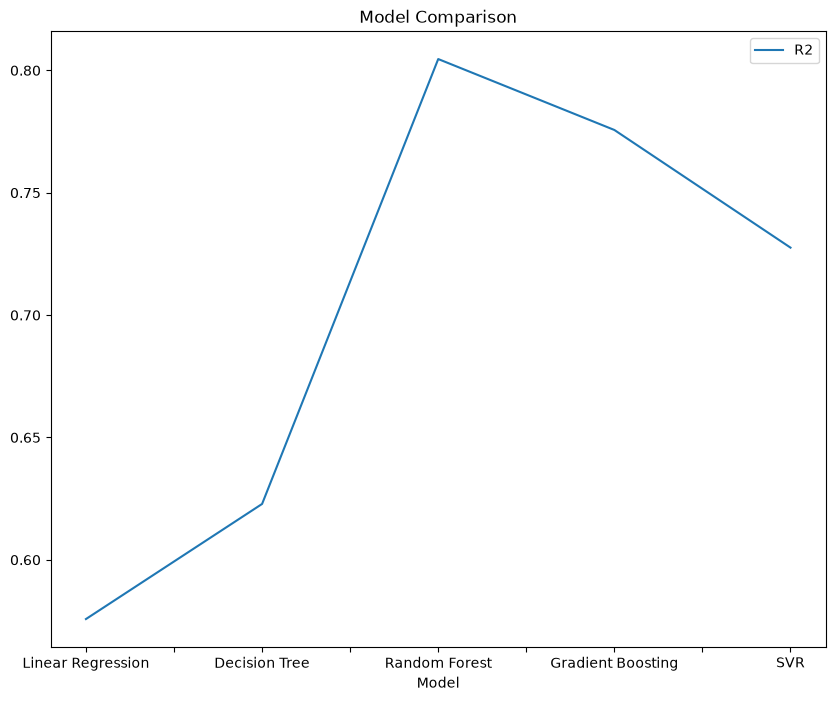

In [34]:

import matplotlib.pyplot as plt

results.plot(
    x="Model",
    y="R2",
    kind="line",
    figsize=(10,8)
)

plt.title("Model Comparison")

plt.show()

Conclusion : Among all regression models,"Random Forest Regressor" achieved the highest R² score and the lowest error metrics, making it the best-performing model.
#Linear Regression showed the weakest performance because housing prices exhibit complex nonlinear relationships that cannot be fully captured by a linear model.
#As per the data,ensemble methods such as Random Forest and Gradient Boosting are more suitable for the California Housing dataset.